# Generative Artificial Intelligence: Illustrations

Supporting notebook for the **Generative AI** chapter.

Sections:
1. Temperature and token sampling
2. Self-attention visualisation
3. Transformer block diagram
4. RAG pipeline diagram
5. Agent loop diagram
6. Multi-agent topology diagrams

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, ArrowStyle
import networkx as nx

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})

FIGDIR = '../markdown/figures/'

## 1. Temperature and Token Sampling

We visualise how the temperature parameter $T$ reshapes the token probability distribution.
For scores $s_i = -\log P_i$, the Gibbs distribution is $\hat{P}_i \propto e^{-s_i/T}$.

- $T \to 0$: mass concentrates on the highest-probability (lowest-score) token
- $T = 1$: original model distribution
- $T \to \infty$: uniform distribution

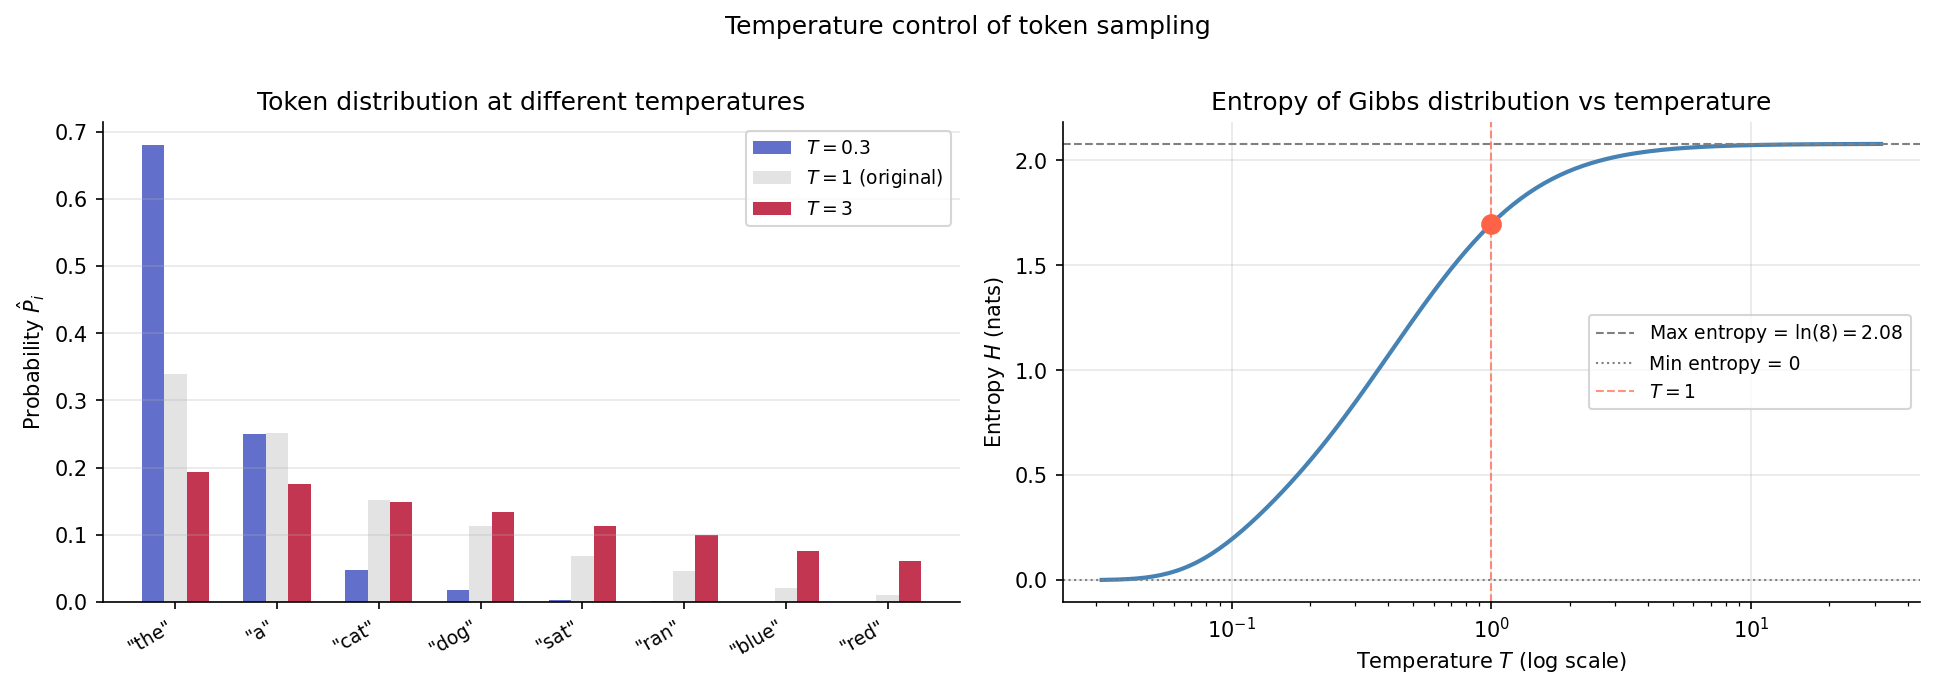

In [2]:
# Toy vocabulary of 8 tokens with illustrative log-probabilities
tokens = ['"the"', '"a"', '"cat"', '"dog"', '"sat"', '"ran"', '"blue"', '"red"']
log_probs = np.array([-0.3, -0.6, -1.1, -1.4, -1.9, -2.3, -3.1, -3.8])  # natural log

# Normalise to a valid distribution
log_probs -= np.log(np.sum(np.exp(log_probs)))
raw_probs = np.exp(log_probs)
scores = -log_probs  # s_i = -log P_i


def gibbs_probs(scores, T):
    logits = -scores / T
    logits -= logits.max()  # numerical stability
    p = np.exp(logits)
    return p / p.sum()


temperatures = [0.2, 0.5, 1.0, 1.5, 3.0]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(temperatures)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart for three representative temperatures
ax = axes[0]
x = np.arange(len(tokens))
width = 0.22
for i, (T, label) in enumerate([(0.3, '$T=0.3$'), (1.0, '$T=1$ (original)'), (3.0, '$T=3$')]):
    p = gibbs_probs(scores, T)
    offset = (i - 1) * width
    ax.bar(x + offset, p, width, label=label, alpha=0.8, color=colors[i * 2])

ax.set_xticks(x)
ax.set_xticklabels(tokens, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Probability $\\hat{P}_i$')
ax.set_title('Token distribution at different temperatures')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: entropy as function of temperature
ax = axes[1]
T_range = np.logspace(-1.5, 1.5, 200)
entropies = []
for T in T_range:
    p = gibbs_probs(scores, T)
    H = -np.sum(p * np.log(p + 1e-15))
    entropies.append(H)

ax.semilogx(T_range, entropies, lw=2, color='steelblue')
ax.axhline(np.log(len(tokens)), color='grey', ls='--', lw=1,
           label=f'Max entropy = $\\ln({len(tokens)}) = {np.log(len(tokens)):.2f}$')
ax.axhline(0, color='grey', ls=':', lw=1, label='Min entropy = 0')

# Mark T=1
H1 = -np.sum(raw_probs * np.log(raw_probs + 1e-15))
ax.axvline(1.0, color='tomato', ls='--', lw=1, alpha=0.7, label='$T=1$')
ax.scatter([1.0], [H1], s=80, color='tomato', zorder=5)

ax.set_xlabel('Temperature $T$ (log scale)')
ax.set_ylabel('Entropy $H$ (nats)')
ax.set_title('Entropy of Gibbs distribution vs temperature')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Temperature control of token sampling', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGDIR + 'gai_temperature.png', bbox_inches='tight')
plt.show()

## 2. Self-Attention Visualisation

We compute and visualise attention weights for a small toy sequence.
The scaled dot-product attention is:
$$\mathrm{Attn}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

We create a synthetic scenario where the query/key representations encode
a simple semantic structure, and visualise the resulting attention matrix.

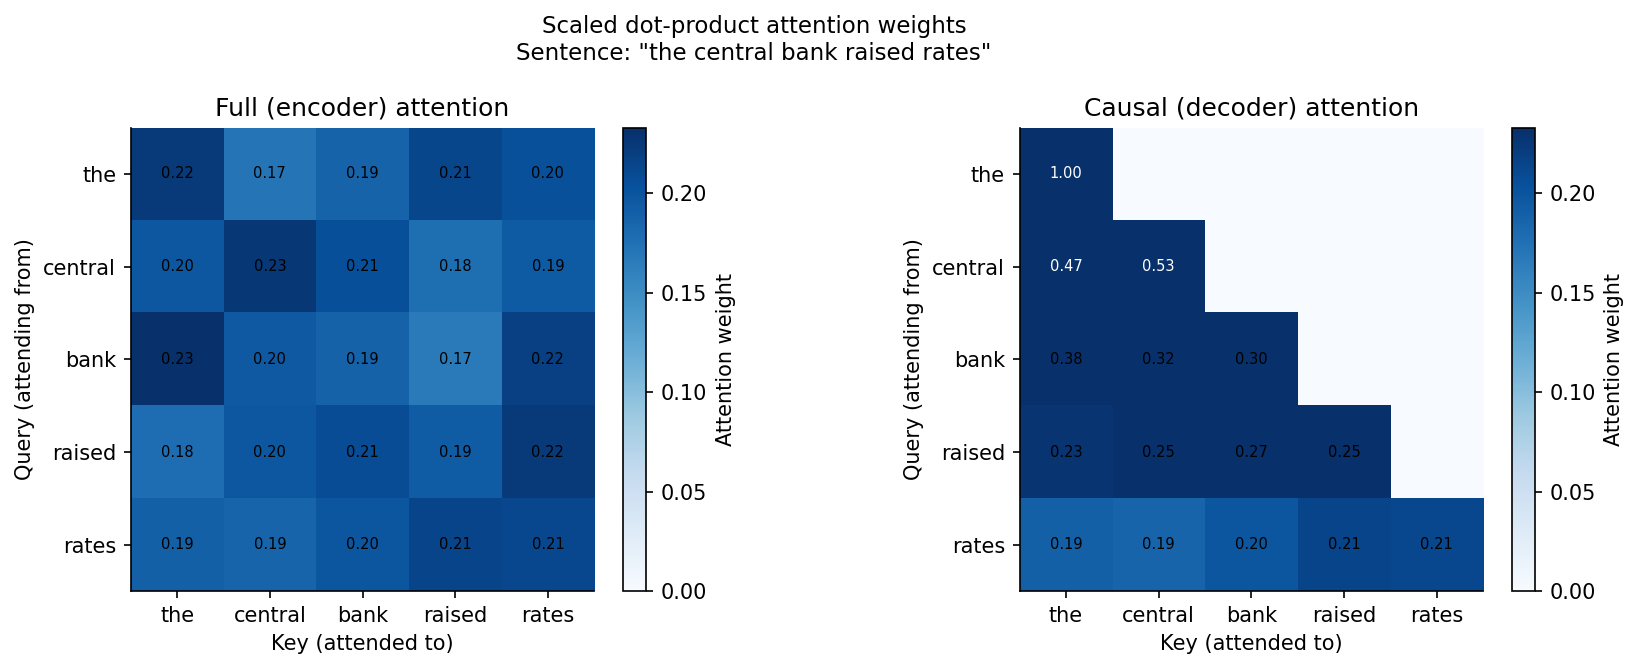

Attention weight matrix (full):
[[0.225 0.172 0.187 0.213 0.204]
 [0.198 0.226 0.205 0.177 0.194]
 [0.233 0.196 0.188 0.166 0.218]
 [0.178 0.198 0.207 0.193 0.224]
 [0.19  0.186 0.199 0.214 0.211]]


In [3]:
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax(scores)
    output = weights @ V
    return output, weights


# Toy sentence: "the central bank raised rates"
tokens_sent = ['the', 'central', 'bank', 'raised', 'rates']
n, d = len(tokens_sent), 8
d_k = 4
rng = np.random.default_rng(42)

# Craft simple embeddings that encode some structure:
# tokens with similar function share components
X = rng.standard_normal((n, d)) * 0.3
# 'central' and 'bank' share a dimension (entity-type)
X[1, 0] = 1.5; X[2, 0] = 1.5
# 'raised' and 'rates' share another (event-related)
X[3, 1] = 1.5; X[4, 1] = 1.5
# 'the' is an article — points at the next token
X[0, 2] = 1.0; X[1, 2] = -0.5

W_Q = rng.standard_normal((d, d_k)) * 0.4
W_K = rng.standard_normal((d, d_k)) * 0.4
W_V = rng.standard_normal((d, d_k)) * 0.4

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

# Full (bidirectional) attention
out_full, W_full = scaled_dot_product_attention(Q, K, V)

# Causal (decoder) attention: lower-triangular mask
causal_mask = np.tril(np.ones((n, n), dtype=bool))
out_causal, W_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, W, title in [
    (axes[0], W_full,   'Full (encoder) attention'),
    (axes[1], W_causal, 'Causal (decoder) attention'),
]:
    im = ax.imshow(W, cmap='Blues', vmin=0, vmax=W_full.max())
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens_sent, fontsize=10)
    ax.set_yticks(range(n)); ax.set_yticklabels(tokens_sent, fontsize=10)
    ax.set_xlabel('Key (attended to)')
    ax.set_ylabel('Query (attending from)')
    ax.set_title(title)
    # Annotate weights
    for i in range(n):
        for j in range(n):
            if W[i, j] > 0.01:
                ax.text(j, i, f'{W[i,j]:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if W[i, j] > 0.4 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Attention weight')

fig.suptitle('Scaled dot-product attention weights\n'
             'Sentence: "the central bank raised rates"', fontsize=11)
fig.tight_layout()
fig.savefig(FIGDIR + 'gai_attention.png', bbox_inches='tight')
plt.show()

print(f'Attention weight matrix (full):\n{np.round(W_full, 3)}')

## 3. Transformer Block Diagram

A schematic of a single Transformer decoder block, showing the flow through:
masked multi-head self-attention → residual + layer norm → feed-forward network → residual + layer norm.

/var/folders/d5/k0x6wwx97k7_73_1cz5q38t40000gn/T/ipykernel_62975/3879753700.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circ = plt.Circle(xy, r, color=color, zorder=3, linewidth=1.2,


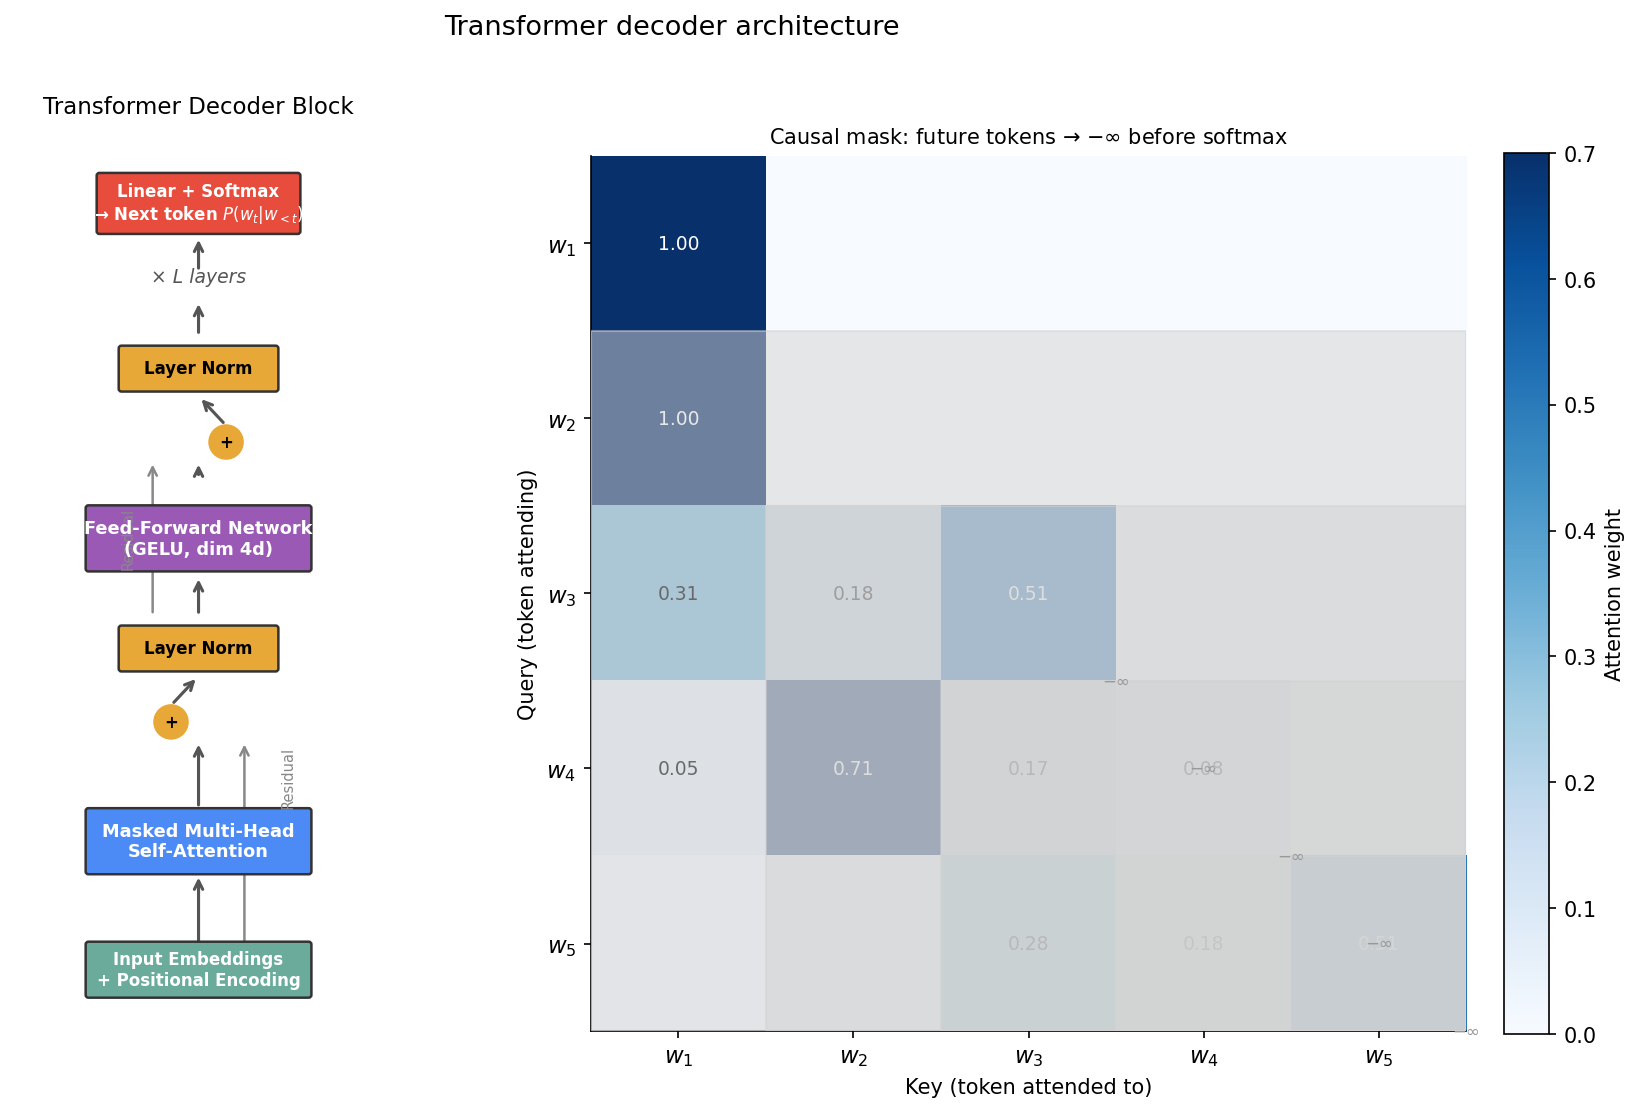

In [4]:
def draw_box(ax, xy, w, h, label, color='#4C8BF5', fontsize=9, text_color='white', radius=0.03):
    x, y = xy
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle=f'round,pad={radius}',
                         linewidth=1.2, edgecolor='#333', facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
            color=text_color, zorder=4, fontweight='bold')


def draw_arrow(ax, xy_from, xy_to, color='#555', lw=1.5):
    ax.annotate('', xy=xy_to, xytext=xy_from,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw),
                zorder=2)


def draw_circle(ax, xy, r, label, color='#E8A838', fontsize=8):
    circ = plt.Circle(xy, r, color=color, zorder=3, linewidth=1.2,
                      edgecolor='#333')
    ax.add_patch(circ)
    ax.text(xy[0], xy[1], label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', zorder=4)


fig, axes = plt.subplots(1, 2, figsize=(13, 7))

# ── LEFT: Transformer decoder block ──────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 4); ax.set_ylim(-0.5, 9.5)
ax.axis('off')
ax.set_aspect('equal')

cx = 2.0  # centre x
bw, bh = 2.4, 0.55  # box width, height
rc = 0.18  # circle radius

# --- bottom to top ---
# Input embeddings + positional encoding
draw_box(ax, (cx, 0.4), bw, bh, 'Input Embeddings\n+ Positional Encoding',
         color='#6AAB9C', fontsize=8)

# Arrow up
draw_arrow(ax, (cx, 0.67), (cx, 1.45))

# Masked MHA
draw_box(ax, (cx, 1.8), bw, bh * 1.2, 'Masked Multi-Head\nSelf-Attention',
         color='#4C8BF5', fontsize=8.5)

# Residual add from input
draw_arrow(ax, (cx, 2.15), (cx, 2.9))
# Residual branch: from bottom of MHA box, bypass right side
ax.annotate('', xy=(cx + 0.5, 2.9), xytext=(cx + 0.5, 0.4),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.2,
                            connectionstyle='arc3,rad=0.0'), zorder=2)

# Add & Norm
draw_circle(ax, (cx - 0.3, 3.1), rc, '+', color='#E8A838')
draw_arrow(ax, (cx - 0.3, 3.28), (cx, 3.6))
draw_box(ax, (cx, 3.9), bw * 0.7, bh * 0.8, 'Layer Norm',
         color='#E8A838', text_color='black', fontsize=8)

# Arrow up
draw_arrow(ax, (cx, 4.25), (cx, 4.7))

# FFN
draw_box(ax, (cx, 5.1), bw, bh * 1.2, 'Feed-Forward Network\n(GELU, dim 4d)',
         color='#9B59B6', fontsize=8.5)

# Residual branch: bypass FFN on left
ax.annotate('', xy=(cx - 0.5, 5.95), xytext=(cx - 0.5, 4.25),
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.2), zorder=2)

draw_arrow(ax, (cx, 5.75), (cx, 5.95))

# Add & Norm 2
draw_circle(ax, (cx + 0.3, 6.15), rc, '+', color='#E8A838')
draw_arrow(ax, (cx + 0.3, 6.33), (cx, 6.65))
draw_box(ax, (cx, 6.95), bw * 0.7, bh * 0.8, 'Layer Norm',
         color='#E8A838', text_color='black', fontsize=8)

# Output arrow
draw_arrow(ax, (cx, 7.3), (cx, 7.7))
ax.text(cx, 7.85, '× L layers', ha='center', va='bottom', fontsize=9,
        style='italic', color='#555')
draw_arrow(ax, (cx, 8.0), (cx, 8.4))

# Linear + Softmax
draw_box(ax, (cx, 8.75), bw * 0.9, bh * 1.1, 'Linear + Softmax\n→ Next token $P(w_t|w_{<t})$',
         color='#E74C3C', fontsize=8)

# Labels
ax.text(cx + 0.9, 2.5, 'Residual', fontsize=7, color='#888', rotation=90, va='center')
ax.text(cx - 0.85, 5.1, 'Residual', fontsize=7, color='#888', rotation=90, va='center')
ax.set_title('Transformer Decoder Block', fontsize=11, pad=10)

# ── RIGHT: Attention score matrix ────────────────────────────────────────────
ax2 = axes[1]
tokens_ex = ['$w_1$', '$w_2$', '$w_3$', '$w_4$', '$w_5$']
n_ex = len(tokens_ex)
rng2 = np.random.default_rng(7)

# Causal attention weights: lower triangular, random but structured
raw = rng2.dirichlet(np.ones(n_ex), size=n_ex)
W_demo = np.tril(raw)
W_demo = W_demo / W_demo.sum(axis=1, keepdims=True)

im = ax2.imshow(W_demo, cmap='Blues', vmin=0, vmax=0.7)
ax2.set_xticks(range(n_ex)); ax2.set_xticklabels(tokens_ex, fontsize=11)
ax2.set_yticks(range(n_ex)); ax2.set_yticklabels(tokens_ex, fontsize=11)
ax2.set_xlabel('Key (token attended to)', fontsize=10)
ax2.set_ylabel('Query (token attending)', fontsize=10)

for i in range(n_ex):
    for j in range(n_ex):
        if W_demo[i, j] > 0.02:
            ax2.text(j, i, f'{W_demo[i,j]:.2f}', ha='center', va='center',
                     fontsize=9, color='white' if W_demo[i, j] > 0.35 else 'black')

# Overlay the causal mask boundary
for k in range(n_ex):
    ax2.add_patch(plt.Rectangle((k - 0.5, k + 0.5), n_ex - k, n_ex - k - 1,
                                 fill=True, color='lightgrey', alpha=0.5, zorder=3))
    ax2.text(k + 0.5 + (n_ex - k - 1) / 2, k + 0.5 + (n_ex - k - 1) / 2,
             '−∞', ha='center', va='center', fontsize=8, color='#999', zorder=4)

plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04, label='Attention weight')
ax2.set_title('Causal mask: future tokens → $-\\infty$ before softmax', fontsize=10)

fig.suptitle('Transformer decoder architecture', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGDIR + 'gai_transformer_block.png', bbox_inches='tight')
plt.show()

## 4. RAG Pipeline Diagram

Schematic of the Retrieval-Augmented Generation pipeline:
offline indexing (chunk → embed → index) and online retrieval (query → embed → ANN search → augment → generate).

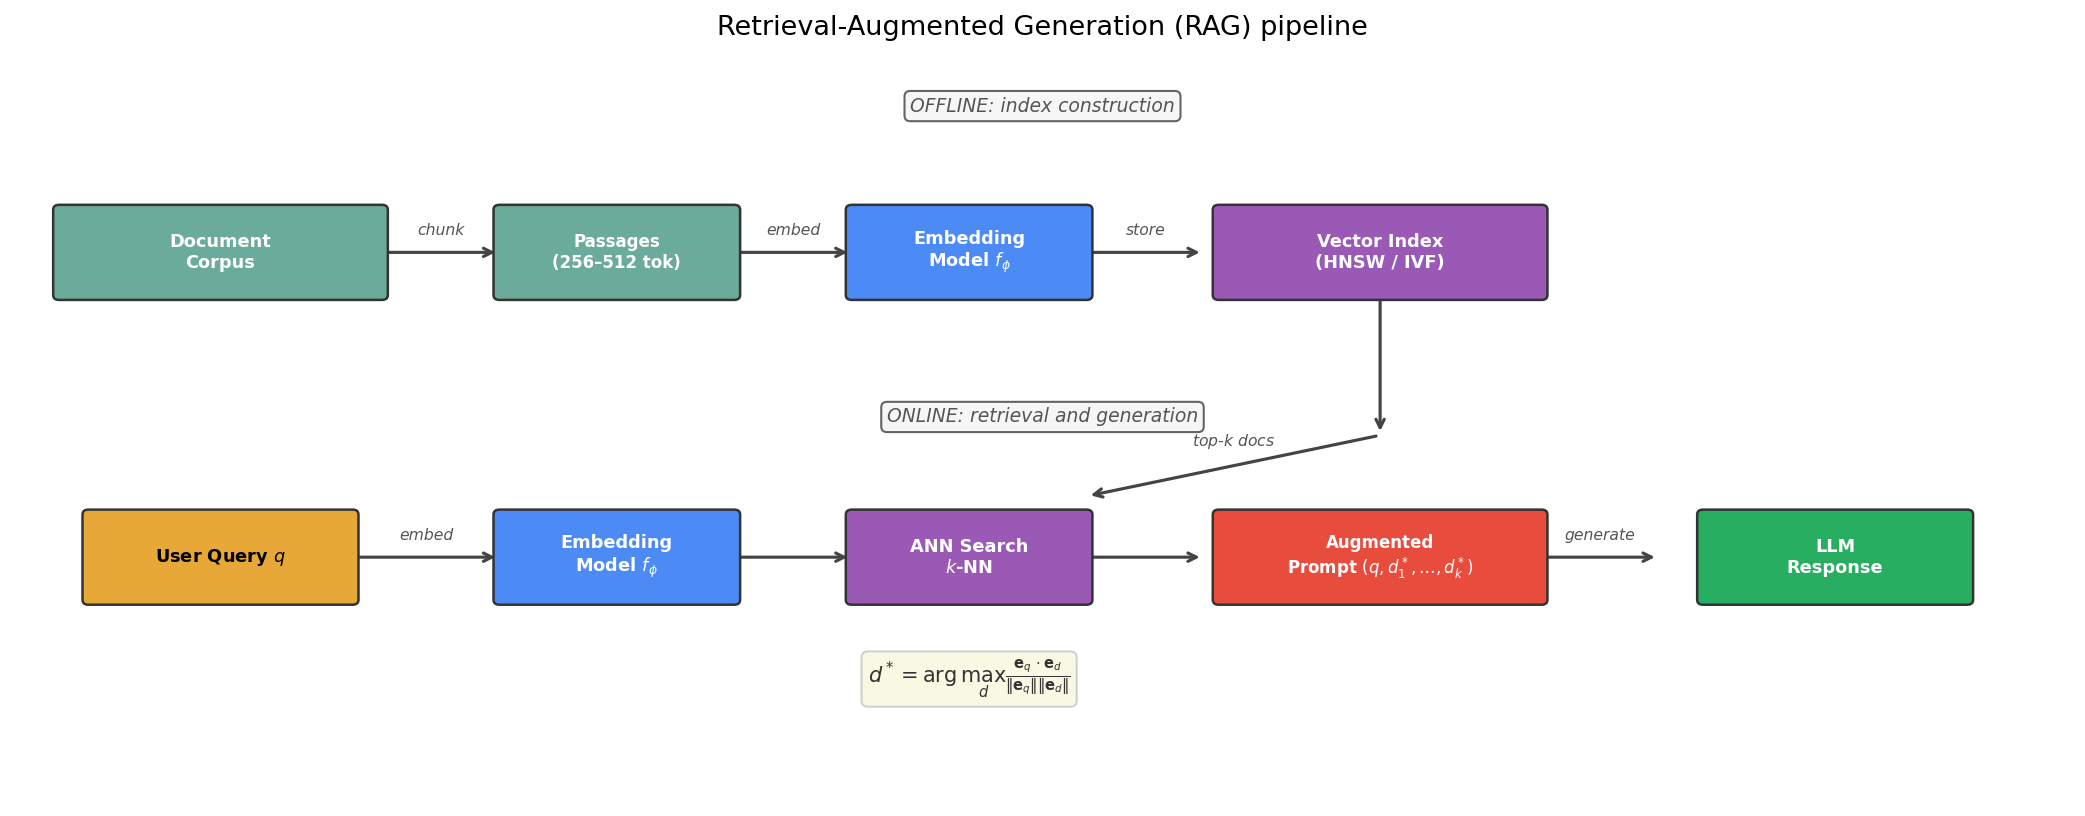

In [5]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_xlim(0, 14); ax.set_ylim(-0.5, 5.5)
ax.axis('off')

def rbox(ax, xy, w, h, label, color, fontsize=8.5, text_color='white'):
    x, y = xy
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.04', lw=1.2,
                         edgecolor='#333', facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
            color=text_color, zorder=4, fontweight='bold',
            multialignment='center')

def rarrow(ax, x0, y0, x1, y1, label='', color='#444', lw=1.5):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw), zorder=2)
    if label:
        mx, my = (x0 + x1) / 2, (y0 + y1) / 2 + 0.12
        ax.text(mx, my, label, ha='center', va='bottom', fontsize=7.5,
                color='#555', style='italic')

# ── OFFLINE PATH (top row, y=4) ──────────────────────────────────────────────
ax.text(7, 5.2, 'OFFLINE: index construction', ha='center', va='center',
        fontsize=9, color='#555', style='italic',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.6))

rbox(ax, (1.4, 4), 2.2, 0.7, 'Document\nCorpus', '#6AAB9C')
rarrow(ax, 2.5, 4, 3.3, 4, 'chunk')
rbox(ax, (4.1, 4), 1.6, 0.7, 'Passages\n(256–512 tok)', '#6AAB9C', fontsize=8)
rarrow(ax, 4.9, 4, 5.7, 4, 'embed')
rbox(ax, (6.5, 4), 1.6, 0.7, 'Embedding\nModel $f_\\phi$', '#4C8BF5')
rarrow(ax, 7.3, 4, 8.1, 4, 'store')
rbox(ax, (9.3, 4), 2.2, 0.7, 'Vector Index\n(HNSW / IVF)', '#9B59B6')

# ── ONLINE PATH (bottom row, y=1.5) ──────────────────────────────────────────
ax.text(7, 2.65, 'ONLINE: retrieval and generation', ha='center', va='center',
        fontsize=9, color='#555', style='italic',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.6))

rbox(ax, (1.4, 1.5), 1.8, 0.7, 'User Query $q$', '#E8A838', text_color='black')
rarrow(ax, 2.3, 1.5, 3.3, 1.5, 'embed')
rbox(ax, (4.1, 1.5), 1.6, 0.7, 'Embedding\nModel $f_\\phi$', '#4C8BF5')
rarrow(ax, 4.9, 1.5, 5.7, 1.5)

# ANN search box (shared with index)
rbox(ax, (6.5, 1.5), 1.6, 0.7, 'ANN Search\n$k$-NN', '#9B59B6')

# Arrow from index down to ANN
rarrow(ax, 9.3, 3.65, 9.3, 2.5)
rarrow(ax, 9.3, 2.5, 7.3, 2.0,  'top-$k$ docs')

rarrow(ax, 7.3, 1.5, 8.1, 1.5)
rbox(ax, (9.3, 1.5), 2.2, 0.7, 'Augmented\nPrompt $(q, d_1^*,\\ldots,d_k^*)$',
     '#E74C3C', fontsize=8)
rarrow(ax, 10.4, 1.5, 11.2, 1.5, 'generate')
rbox(ax, (12.4, 1.5), 1.8, 0.7, 'LLM\nResponse', '#27AE60')

# Similarity formula annotation
ax.text(6.5, 0.5,
        r'$d^* = \arg\max_{d} \frac{\mathbf{e}_q \cdot \mathbf{e}_d}{\|\mathbf{e}_q\|\|\mathbf{e}_d\|}$',
        ha='center', va='center', fontsize=10, color='#333',
        bbox=dict(boxstyle='round', facecolor='#f9f9e0', edgecolor='#ccc', alpha=0.9))

fig.suptitle('Retrieval-Augmented Generation (RAG) pipeline', fontsize=13)
fig.tight_layout()
fig.savefig(FIGDIR + 'gai_rag_pipeline.png', bbox_inches='tight')
plt.show()

## 5. Agent Loop Diagram

Schematic of the ReAct agent loop: Thought → Action → Observation → (repeat) → Final Answer.

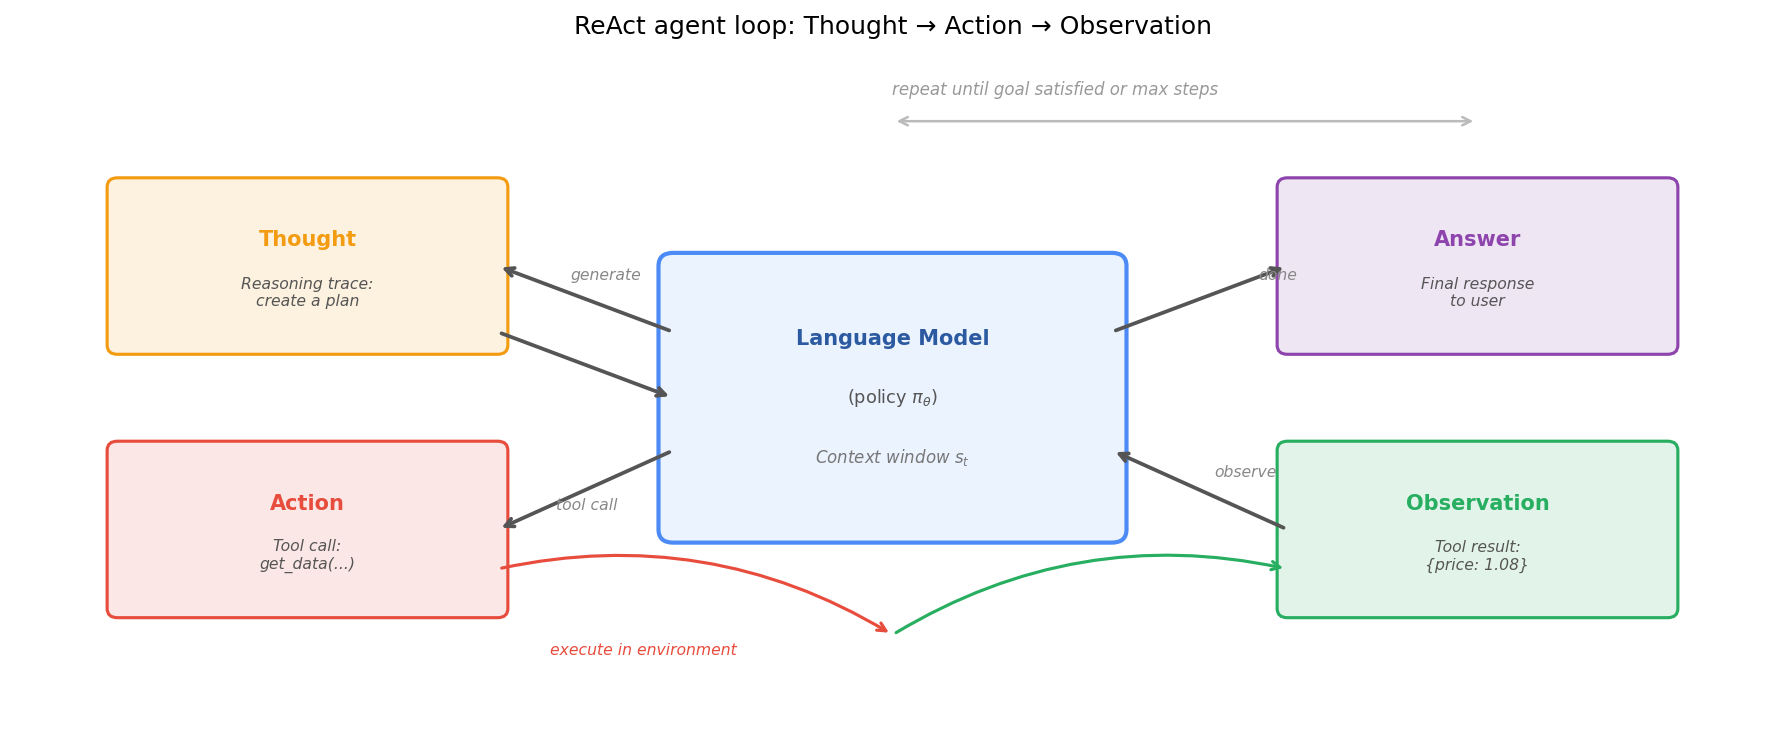

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12); ax.set_ylim(0, 5)
ax.axis('off')

# Central LLM core
llm_box = FancyBboxPatch((4.5, 1.5), 3.0, 2.0,
                          boxstyle='round,pad=0.1', lw=2,
                          edgecolor='#4C8BF5', facecolor='#EBF3FF', zorder=3)
ax.add_patch(llm_box)
ax.text(6.0, 2.95, 'Language Model', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#2c5aa0', zorder=4)
ax.text(6.0, 2.5, '(policy $\\pi_\\theta$)', ha='center', va='center',
        fontsize=8.5, color='#555', zorder=4)
ax.text(6.0, 2.05, 'Context window $s_t$', ha='center', va='center',
        fontsize=8, color='#777', style='italic', zorder=4)

colors_step = {'Thought': '#F39C12', 'Action': '#E74C3C',
               'Observation': '#27AE60', 'Answer': '#8E44AD'}

# Steps arranged around the LLM box
steps = [
    ('Thought', 2.0, 3.5, 'Reasoning trace:\ncreate a plan'),
    ('Action', 2.0, 1.5, 'Tool call:\nget_data(...)'),
    ('Observation', 10.0, 1.5, 'Tool result:\n{price: 1.08}'),
    ('Answer', 10.0, 3.5, 'Final response\nto user'),
]

for name, x, y, desc in steps:
    c = colors_step[name]
    box = FancyBboxPatch((x - 1.3, y - 0.6), 2.6, 1.2,
                          boxstyle='round,pad=0.07', lw=1.5,
                          edgecolor=c, facecolor=c + '22', zorder=3)
    ax.add_patch(box)
    ax.text(x, y + 0.2, name, ha='center', va='center',
            fontsize=10, fontweight='bold', color=c, zorder=4)
    ax.text(x, y - 0.2, desc, ha='center', va='center',
            fontsize=7.5, color='#555', zorder=4, style='italic')

# Arrows
arrow_kw = dict(arrowstyle='->', lw=1.8, color='#555')

# LLM → Thought
ax.annotate('', xy=(3.3, 3.5), xytext=(4.5, 3.0),
            arrowprops=dict(**arrow_kw))
ax.text(3.8, 3.4, 'generate', fontsize=7.5, color='#888', style='italic')

# Thought → LLM (thought appended to context)
ax.annotate('', xy=(4.5, 2.5), xytext=(3.3, 3.0),
            arrowprops=dict(**arrow_kw))

# LLM → Action
ax.annotate('', xy=(3.3, 1.5), xytext=(4.5, 2.1),
            arrowprops=dict(**arrow_kw))
ax.text(3.7, 1.65, 'tool call', fontsize=7.5, color='#888', style='italic')

# Action → Tool environment (bottom)
ax.annotate('', xy=(6.0, 0.7), xytext=(3.3, 1.2),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#E74C3C',
                            connectionstyle='arc3,rad=-0.2'))
ax.text(4.3, 0.55, 'execute in environment', fontsize=7.5,
        color='#E74C3C', ha='center', style='italic')

# Tool environment → Observation
ax.annotate('', xy=(8.7, 1.2), xytext=(6.0, 0.7),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='#27AE60',
                            connectionstyle='arc3,rad=-0.2'))

# Observation → LLM (observation appended to context)
ax.annotate('', xy=(7.5, 2.1), xytext=(8.7, 1.5),
            arrowprops=dict(**arrow_kw))
ax.text(8.2, 1.9, 'observe', fontsize=7.5, color='#888', style='italic')

# LLM → Answer
ax.annotate('', xy=(8.7, 3.5), xytext=(7.5, 3.0),
            arrowprops=dict(**arrow_kw))
ax.text(8.5, 3.4, 'done', fontsize=7.5, color='#888', style='italic')

# Loop annotation
ax.annotate('', xy=(6.0, 4.6), xytext=(10.0, 4.6),
            arrowprops=dict(arrowstyle='<->', lw=1.2, color='#bbb'))
ax.text(6.0, 4.8, 'repeat until goal satisfied or max steps', ha='left',
        fontsize=8, color='#999', style='italic')

fig.suptitle('ReAct agent loop: Thought → Action → Observation', fontsize=12)
fig.tight_layout()
fig.savefig(FIGDIR + 'gai_agent_loop.png', bbox_inches='tight')
plt.show()

## 6. Multi-Agent Topology Diagrams

Six canonical multi-agent topologies, drawn using NetworkX:
(a) Linear / pipeline, (b) Supervisor / hub-and-spoke, (c) Hierarchical,
(d) Actor-critic, (e) DAG, (f) Swarm.

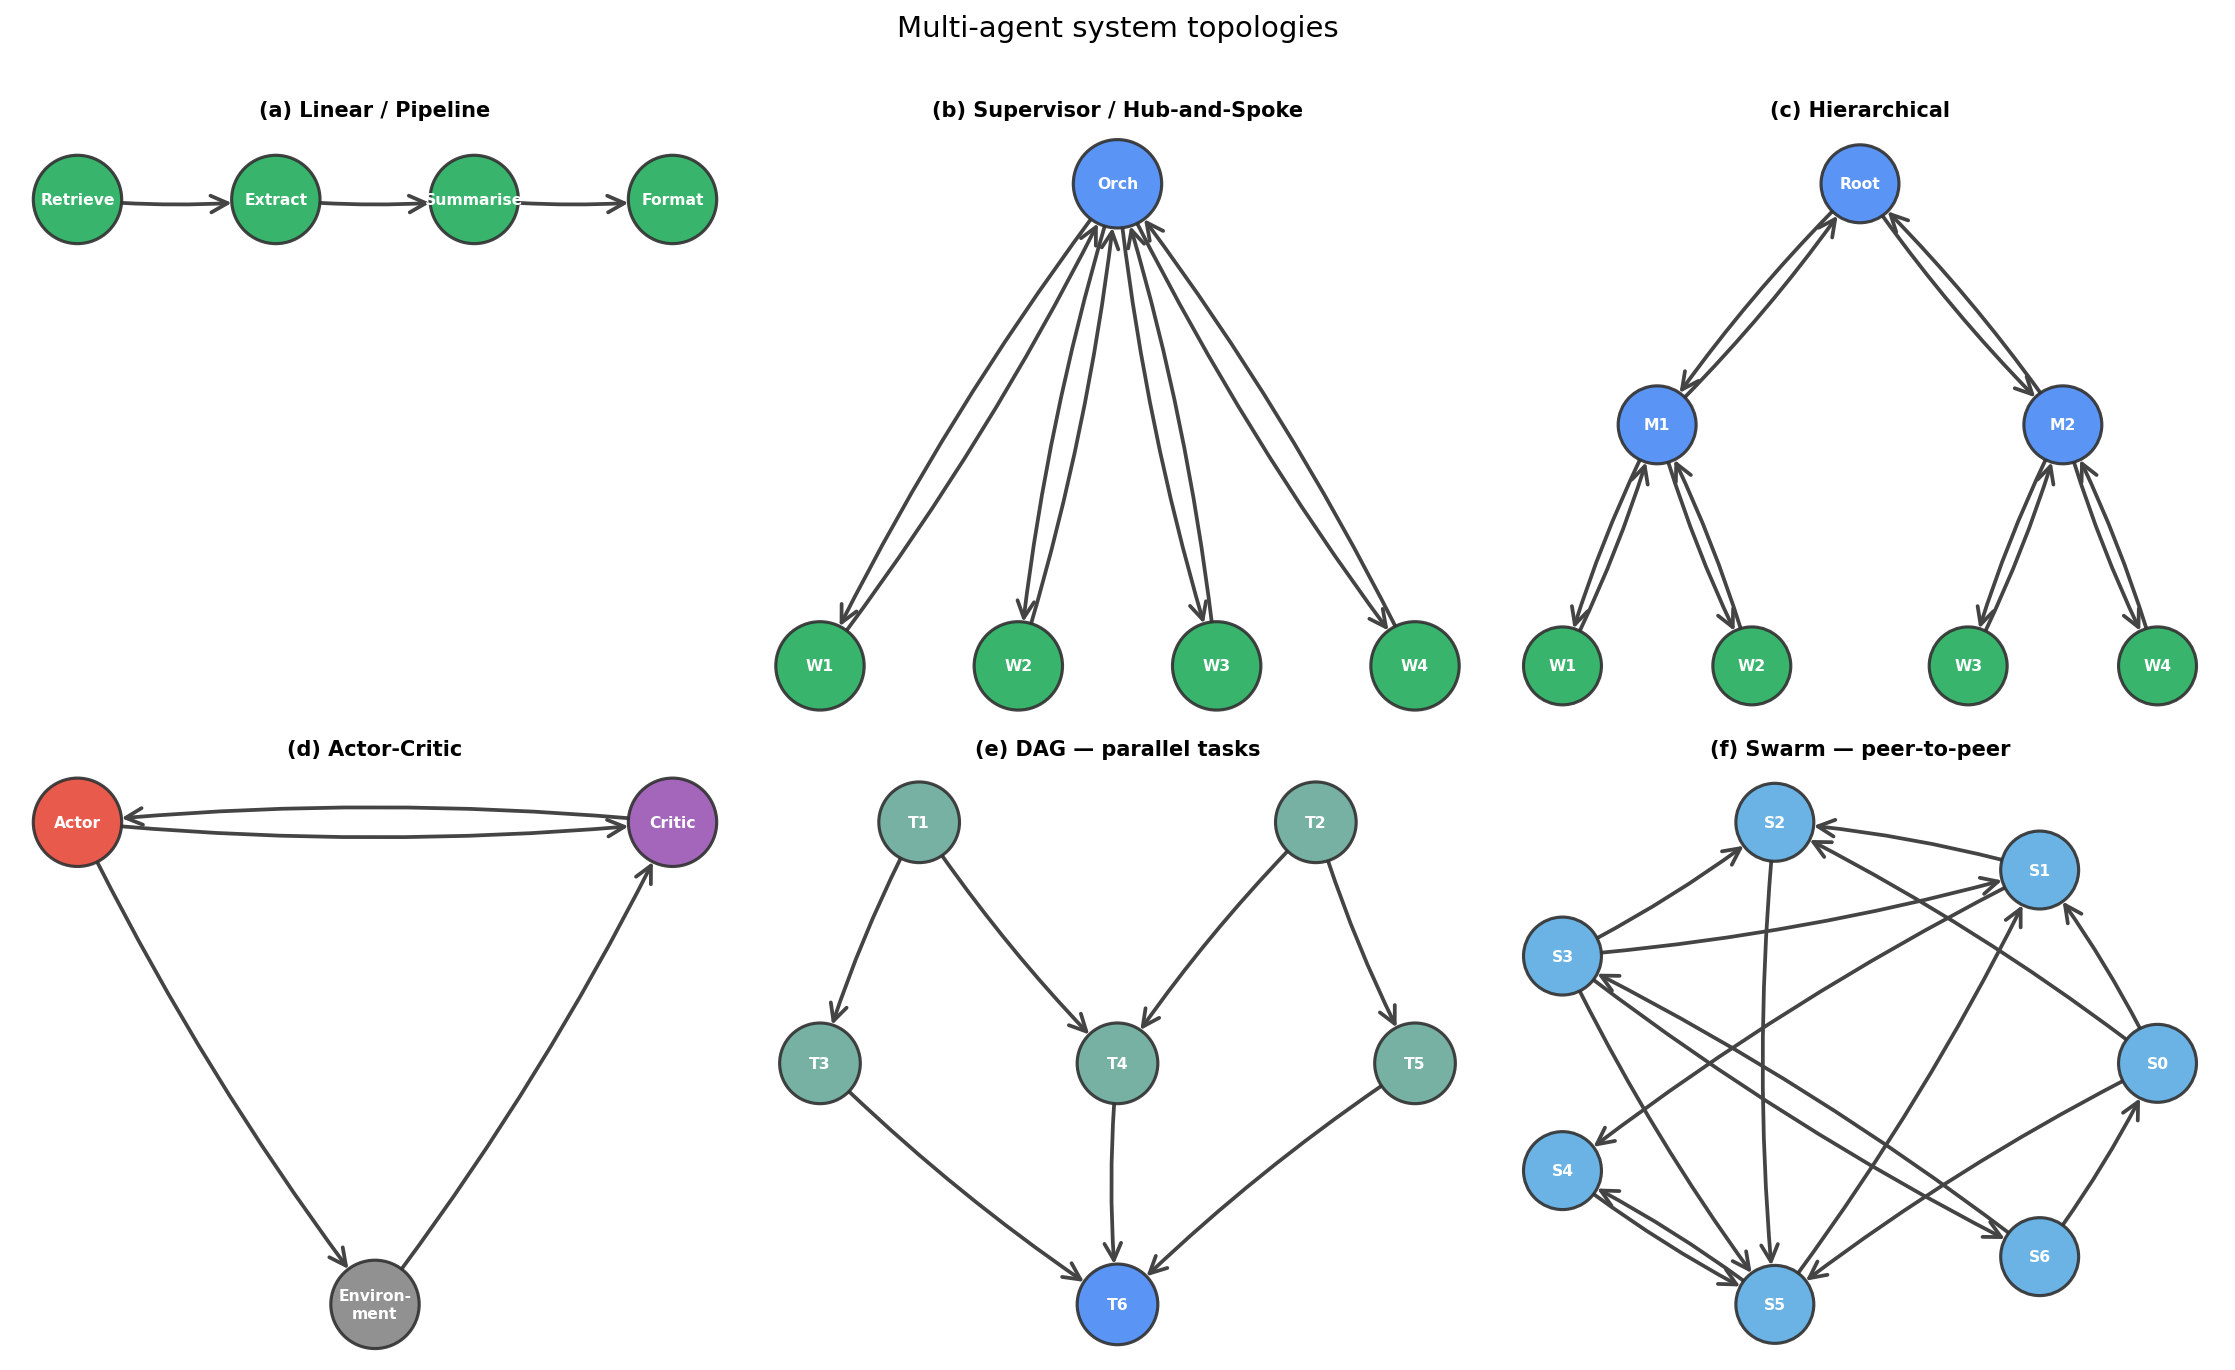

In [7]:
def draw_agent_graph(ax, G, pos, node_colors, node_labels, title,
                     edge_labels=None, node_size=1800):
    """Draw a directed agent topology graph on axes ax."""
    ax.set_title(title, fontsize=10, pad=8, fontweight='bold')
    ax.axis('off')

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size,
                           node_color=node_colors, alpha=0.92, linewidths=1.5,
                           edgecolors='#333')
    nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                            font_size=7.5, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True,
                           arrowstyle='->', arrowsize=20, width=1.8,
                           edge_color='#444', node_size=node_size,
                           connectionstyle='arc3,rad=0.05')
    if edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                     font_size=6.5, label_pos=0.4)


ORCH = '#4C8BF5'   # orchestrator / supervisor
WORK = '#27AE60'   # worker
USER = '#E8A838'   # user / external
ACTOR = '#E74C3C'  # actor
CRITIC = '#9B59B6' # critic / evaluator
PEER = '#5DADE2'   # peer agent

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# ── (a) Linear / pipeline ────────────────────────────────────────────────────
ax = axes[0]
G = nx.DiGraph()
nodes = ['A1', 'A2', 'A3', 'A4']
G.add_nodes_from(nodes)
G.add_edges_from([('A1', 'A2'), ('A2', 'A3'), ('A3', 'A4')])
pos = {n: (i, 0) for i, n in enumerate(nodes)}
colors = [WORK] * 4
labels = {'A1': 'Retrieve', 'A2': 'Extract', 'A3': 'Summarise', 'A4': 'Format'}
draw_agent_graph(ax, G, pos, colors, labels, '(a) Linear / Pipeline')

# ── (b) Supervisor / hub-and-spoke ───────────────────────────────────────────
ax = axes[1]
G = nx.DiGraph()
workers = ['W1', 'W2', 'W3', 'W4']
G.add_node('Orch')
G.add_nodes_from(workers)
for w in workers:
    G.add_edge('Orch', w)   # dispatch
    G.add_edge(w, 'Orch')   # result
pos = {'Orch': (0, 0),
       'W1': (-1.5, -1.5), 'W2': (-0.5, -1.5),
       'W3': (0.5, -1.5),  'W4': (1.5, -1.5)}
c = {'Orch': ORCH, 'W1': WORK, 'W2': WORK, 'W3': WORK, 'W4': WORK}
l = {'Orch': 'Orch', 'W1': 'W1', 'W2': 'W2', 'W3': 'W3', 'W4': 'W4'}
draw_agent_graph(ax, G, pos, [c[n] for n in G.nodes()],
                 l, '(b) Supervisor / Hub-and-Spoke')

# ── (c) Hierarchical ─────────────────────────────────────────────────────────
ax = axes[2]
G = nx.DiGraph()
nodes_h = ['Root', 'M1', 'M2', 'W1', 'W2', 'W3', 'W4']
G.add_nodes_from(nodes_h)
G.add_edges_from([('Root','M1'), ('Root','M2'),
                  ('M1','W1'), ('M1','W2'),
                  ('M2','W3'), ('M2','W4'),
                  ('W1','M1'), ('W2','M1'),
                  ('W3','M2'), ('W4','M2'),
                  ('M1','Root'), ('M2','Root')])
pos_h = {'Root': (0, 0), 'M1': (-1.5, -1.2), 'M2': (1.5, -1.2),
          'W1': (-2.2, -2.4), 'W2': (-0.8, -2.4),
          'W3': (0.8, -2.4),  'W4': (2.2, -2.4)}
c_h = {'Root': ORCH, 'M1': ORCH, 'M2': ORCH,
       'W1': WORK, 'W2': WORK, 'W3': WORK, 'W4': WORK}
l_h = {n: n for n in nodes_h}
draw_agent_graph(ax, G, pos_h, [c_h[n] for n in G.nodes()],
                 l_h, '(c) Hierarchical', node_size=1400)

# ── (d) Actor-critic ─────────────────────────────────────────────────────────
ax = axes[3]
G = nx.DiGraph()
G.add_nodes_from(['Actor', 'Critic', 'Env'])
G.add_edges_from([('Actor', 'Env'),    # proposes action
                  ('Env', 'Critic'),   # outcome observed by critic
                  ('Critic', 'Actor'), # feedback to actor
                  ('Actor', 'Critic')]) # draft sent to critic pre-execution
pos_ac = {'Actor': (-1.2, 0), 'Critic': (1.2, 0), 'Env': (0, -1.5)}
c_ac = {'Actor': ACTOR, 'Critic': CRITIC, 'Env': '#888'}
l_ac = {'Actor': 'Actor', 'Critic': 'Critic', 'Env': 'Environ-\nment'}
draw_agent_graph(ax, G, pos_ac, [c_ac[n] for n in G.nodes()],
                 l_ac, '(d) Actor-Critic')

# ── (e) DAG ──────────────────────────────────────────────────────────────────
ax = axes[4]
G = nx.DiGraph()
G.add_nodes_from(['T1', 'T2', 'T3', 'T4', 'T5', 'T6'])
G.add_edges_from([('T1','T3'), ('T1','T4'),
                  ('T2','T4'), ('T2','T5'),
                  ('T3','T6'), ('T4','T6'), ('T5','T6')])
pos_dag = {'T1': (-1, 0), 'T2': (1, 0),
           'T3': (-1.5, -1.2), 'T4': (0, -1.2), 'T5': (1.5, -1.2),
           'T6': (0, -2.4)}
c_dag = ['#6AAB9C'] * 5 + [ORCH]
l_dag = {n: n for n in G.nodes()}
draw_agent_graph(ax, G, pos_dag, [c_dag[i] for i, n in enumerate(G.nodes())],
                 l_dag, '(e) DAG — parallel tasks', node_size=1500)

# ── (f) Swarm ────────────────────────────────────────────────────────────────
ax = axes[5]
n_swarm = 7
G = nx.DiGraph()
swarm_nodes = [f'S{i}' for i in range(n_swarm)]
G.add_nodes_from(swarm_nodes)
rng_g = np.random.default_rng(3)
# Random sparse peer-to-peer edges
for i in range(n_swarm):
    for j in range(n_swarm):
        if i != j and rng_g.random() < 0.35:
            G.add_edge(swarm_nodes[i], swarm_nodes[j])
theta_sw = np.linspace(0, 2 * np.pi, n_swarm, endpoint=False)
pos_sw = {swarm_nodes[i]: (np.cos(theta_sw[i]), np.sin(theta_sw[i]))
          for i in range(n_swarm)}
draw_agent_graph(ax, G, pos_sw, [PEER] * n_swarm,
                 {n: n for n in swarm_nodes}, '(f) Swarm — peer-to-peer',
                 node_size=1400)

fig.suptitle('Multi-agent system topologies', fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(FIGDIR + 'gai_agent_topologies.png', bbox_inches='tight')
plt.show()

## 7. LoRA Parameter Efficiency

We visualise how the number of trainable parameters in LoRA scales with rank $r$,
as a fraction of the full fine-tuning parameter count for weight matrices of different sizes.

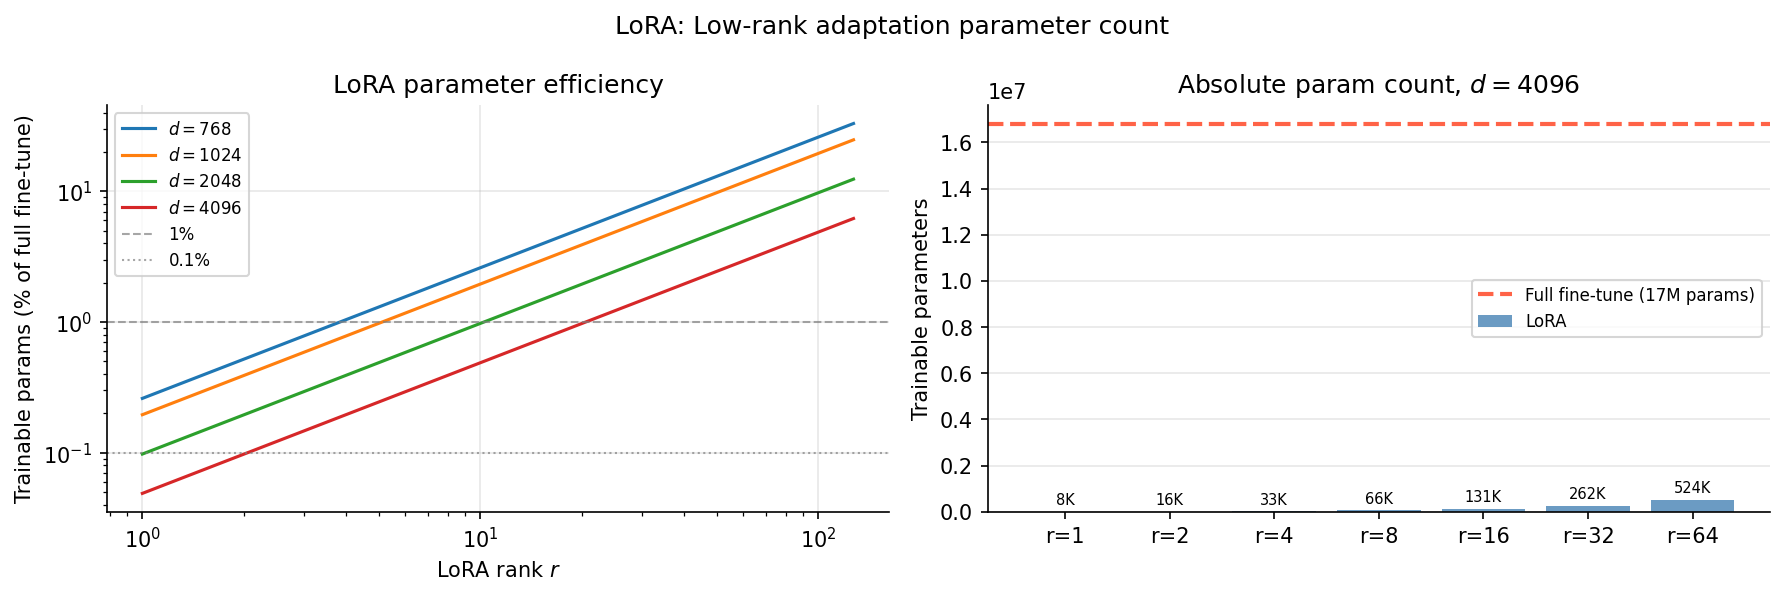

In [8]:
dims = [768, 1024, 2048, 4096]  # typical model dimensions
ranks = np.arange(1, 128)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for d in dims:
    full_params = d * d
    lora_params = ranks * (d + d)  # r*(d+k), d=k for square matrices
    frac = lora_params / full_params * 100
    ax.loglog(ranks, frac, lw=1.5, label=f'$d={d}$')

ax.axhline(1, color='grey', ls='--', lw=1, alpha=0.7, label='1%')
ax.axhline(0.1, color='grey', ls=':', lw=1, alpha=0.7, label='0.1%')
ax.set_xlabel('LoRA rank $r$')
ax.set_ylabel('Trainable params (% of full fine-tune)')
ax.set_title('LoRA parameter efficiency')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: absolute parameter counts
ax = axes[1]
d = 4096
selected_ranks = [1, 2, 4, 8, 16, 32, 64]
full_p = d * d
lora_p = [r * (d + d) for r in selected_ranks]
bars = ax.bar(range(len(selected_ranks)), lora_p, color='steelblue', alpha=0.8,
              label='LoRA')
ax.axhline(full_p, color='tomato', lw=2, ls='--', label=f'Full fine-tune ({full_p/1e6:.0f}M params)')
ax.set_xticks(range(len(selected_ranks)))
ax.set_xticklabels([f'r={r}' for r in selected_ranks])
ax.set_ylabel('Trainable parameters')
ax.set_title(f'Absolute param count, $d={d}$')
ax.legend(fontsize=8)
for bar, p in zip(bars, lora_p):
    ax.text(bar.get_x() + bar.get_width()/2, p + full_p * 0.01,
            f'{p/1e3:.0f}K', ha='center', va='bottom', fontsize=7)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('LoRA: Low-rank adaptation parameter count', fontsize=12)
fig.tight_layout()
fig.savefig(FIGDIR + 'gai_lora.png', bbox_inches='tight')
plt.show()